In [1]:
from helpers.load import *
from helpers.select_scenario import select_scenario
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
scenario_folder_air = Path(os.path.abspath('')) / 'logs' / 'unified' / 'air'
scenario_folder_freshwater = Path(os.path.abspath('')) / 'logs' / 'unified' / 'freshwater'

In [3]:
def load_scenario_aggregate_df(scenario_folder, loader_function):
    node_pos_df = pd.DataFrame()
    for config_folder in sorted([folder for folder in scenario_folder.iterdir() if folder.is_dir()]):
        temp_df = loader_function(config_folder)
        temp_df['Config'] = config_folder.name
        node_pos_df = pd.concat([node_pos_df, temp_df])
    
    return node_pos_df.reset_index(drop=True)

node_pos_df_freshwater = load_scenario_aggregate_df(scenario_folder_freshwater, load_node_pos_df)
phy_tx_begin_freshwater = load_scenario_aggregate_df(scenario_folder_freshwater, load_phy_tx_begin)
phy_rx_end_freshwater = load_scenario_aggregate_df(scenario_folder_freshwater, load_phy_rx_end)

node_pos_df_air = load_scenario_aggregate_df(scenario_folder_air, load_node_pos_df)
phy_tx_begin_air = load_scenario_aggregate_df(scenario_folder_air, load_phy_tx_begin)
phy_rx_end_air = load_scenario_aggregate_df(scenario_folder_air, load_phy_rx_end)

In [4]:
# Append the most recent node positions (X, Y, Z) for SourceNodeId and DestinationNodeId at the time of the packet in each of the dataframes. Add a column for Distance
def append_node_pos(packet_df, node_pos_df, column):
    # Group node_pos_df by NodeId and Config
    for config in packet_df['Config'].unique():
        # Get packets and node positions for this config
        config_mask = packet_df['Config'] == config
        node_pos_mask = node_pos_df['Config'] == config
        
        # Create position mapping for this config
        pos_map = node_pos_df[node_pos_mask].set_index('NodeId')
        
        # Map positions for packets in this config
        packet_df.loc[config_mask, f'{column}_X'] = packet_df.loc[config_mask, column].map(pos_map['X'])
        packet_df.loc[config_mask, f'{column}_Y'] = packet_df.loc[config_mask, column].map(pos_map['Y'])
        packet_df.loc[config_mask, f'{column}_Z'] = packet_df.loc[config_mask, column].map(pos_map['Z'])
        packet_df.loc[config_mask, f'{column}_NodeType'] = packet_df.loc[config_mask, column].map(pos_map['NodeType'])
    
append_node_pos(phy_tx_begin_freshwater, node_pos_df_freshwater, 'SourceNodeId')
append_node_pos(phy_rx_end_freshwater, node_pos_df_freshwater, 'DestinationNodeId')
append_node_pos(phy_tx_begin_air, node_pos_df_air, 'SourceNodeId')
append_node_pos(phy_rx_end_air, node_pos_df_air, 'DestinationNodeId')

In [5]:
def calculate_packet_stats(tx_begin_df, rx_end_df):
    packet_df = rx_end_df.copy()
    # Drop the SnifferNodeId column
    packet_df.drop(columns=['SnifferNodeId'], inplace=True)
    # Rename Time into TxTime
    packet_df.rename(columns={'Time': 'RxTime'}, inplace=True)
    
    def get_tx_values(packet_id, config, df, column):
        values = df[(df['PacketId'] == packet_id) & (df['Config'] == config)][column].values
        return values if len(values) > 0 else np.array([np.nan])
    
    # Append a column with the time the same PacketId is registered for the first time in tx_begin_df
    packet_df['TxTime'] = packet_df.apply(lambda x: get_tx_values(x['PacketId'], x['Config'], tx_begin_df, 'Time')[0], axis=1)
    # If TxTime is NaN, set it to -inf
    packet_df['TxTime'] = packet_df['TxTime'].apply(lambda x: -np.inf if np.isnan(x) else x)
    # Calculate the time the packet spent in the air
    packet_df['AirTime'] = packet_df['RxTime'] - packet_df['TxTime']
    
    # Append the SourceNodeId columns with values from tx_begin_df matching both PacketId and Config
    for col in ['SourceNodeId_X', 'SourceNodeId_Y', 'SourceNodeId_Z', 'SourceNodeId_NodeType']:
        packet_df[col] = packet_df.apply(lambda x: get_tx_values(x['PacketId'], x['Config'], tx_begin_df, col)[-1], axis=1)
    
    # Drop packets where any SourceNodeId column is NaN
    for col in ['SourceNodeId_X', 'SourceNodeId_Y', 'SourceNodeId_Z', 'SourceNodeId_NodeType']:
        packet_df.dropna(subset=[col], inplace=True)
    
    # Calculate distance between source and destination nodes
    packet_df['Distance'] = np.sqrt(
        (packet_df['SourceNodeId_X'] - packet_df['DestinationNodeId_X'])**2 + 
        (packet_df['SourceNodeId_Y'] - packet_df['DestinationNodeId_Y'])**2 + 
        (packet_df['SourceNodeId_Z'] - packet_df['DestinationNodeId_Z'])**2
    )

    return packet_df

packet_stats_freshwater = calculate_packet_stats(phy_tx_begin_freshwater, phy_rx_end_freshwater)
packet_stats_air = calculate_packet_stats(phy_tx_begin_air, phy_rx_end_air)


In [64]:
# Group the packet_stats_freshwater by Distance. Then calculate the average throughput by dividing the sum of the packet sizes by the sum of the AirTime
def calculate_throughput(packet_stats_df):
    throughput_df = packet_stats_df[
            (packet_stats_df['SourceNodeId_NodeType'] == 'STA') & 
            (packet_stats_df['DestinationNodeId_NodeType'] == 'AP') &
            (packet_stats_df['PacketSize'] >= 100)
        ].groupby('Distance').agg({
            'PacketSize': 'sum', 
            'AirTime': 'sum',
            'PacketId': 'count'
        })
    # Convert AirTime from ns to s
    throughput_df['AirTime'] = throughput_df['AirTime'] / 1e9
    throughput_df['Throughput'] = throughput_df['PacketSize'] / throughput_df['AirTime']
    return throughput_df

throughput_freshwater = calculate_throughput(packet_stats_freshwater)
throughput_air = calculate_throughput(packet_stats_air)

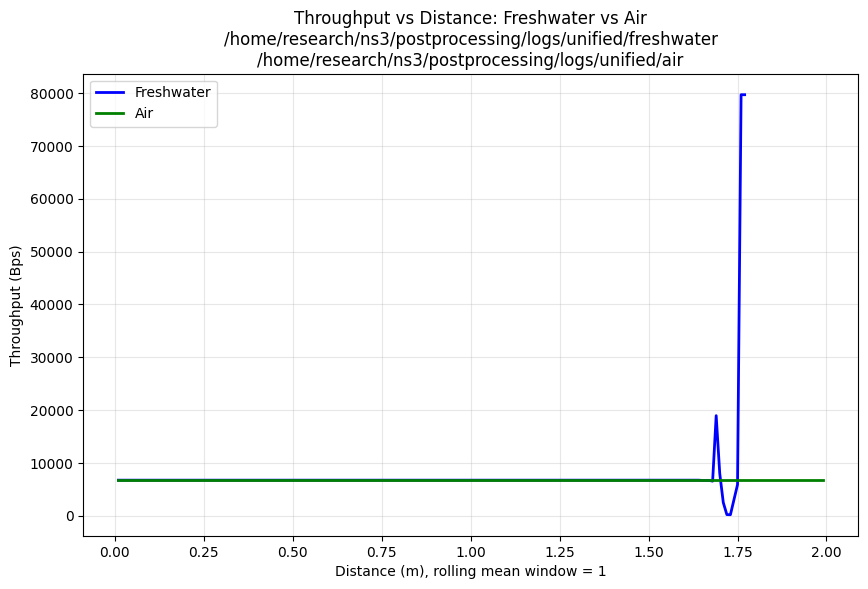

In [67]:
plt.figure(figsize=(10, 6))

# Plot rolling averages as solid lines
plt.plot(throughput_freshwater.index, throughput_freshwater['Throughput'].rolling(window=1, min_periods=1).mean(), 
         label='Freshwater', color='blue', linewidth=2)
plt.plot(throughput_air.index, throughput_air['Throughput'].rolling(window=1, min_periods=1).mean(), 
         label='Air', color='green', linewidth=2)

plt.xlabel('Distance (m), rolling mean window = 1')
plt.ylabel('Throughput (Bps)')
plt.title(f'Throughput vs Distance: Freshwater vs Air\n{scenario_folder_freshwater}\n{scenario_folder_air}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [63]:
throughput_freshwater.tail(20)

,PacketSize,AirTime,PacketId,Throughput
Distance,,,,
1.580032,6928,1.028920,12,6733.270648
1.590031,6928,1.028920,12,6733.270648
1.600031,6928,1.028920,12,6733.270648
1.610031,6928,1.028920,12,6733.270648
1.620031,6928,1.028920,12,6733.270583
1.630031,6928,1.028920,12,6733.270583
1.640030,6928,1.028920,12,6733.270583
1.650030,6928,1.035438,12,6690.885134
1.660030,6928,1.034866,12,6694.583376
